(1, 301, 3)


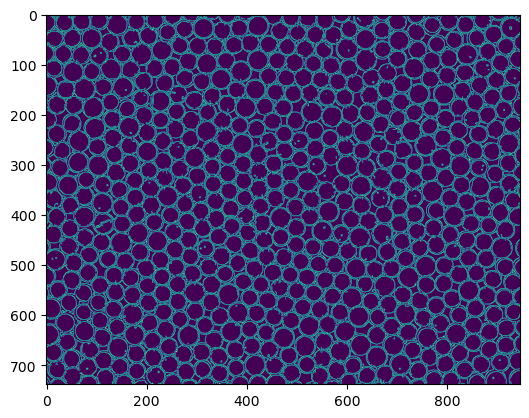

In [140]:
# Q 10
import cv2
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.cm as cm


img = cv2.imread('images/circles.jpg')
img_1 = img.copy()
# Changing the order from bgr to rgb so that matplotlib can show it
b,g,r = cv2.split(img)
#img = cv2.merge([r,g,b])
#plt.imshow(img)

gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
#plt.imshow(gray, cmap=cm.gray)

edges = cv2.Canny(gray, 100, 200)
plt.imshow(edges)

circles = cv2.HoughCircles(edges, cv2.HOUGH_GRADIENT, dp=1, minDist=20,param1=50, param2=30, minRadius=10, maxRadius=50)
#plt.imshow(circles)
print(circles.shape)

In [26]:
def cornerHarrisDetection(img_gray):
    block_size = 5
    ksize = 11
    k = 0.09
    corner_response = cv2.cornerHarris(img_gray, block_size, ksize, k)
    
    # Normalize the corner response map
    corner_response_norm = cv2.normalize(corner_response, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    
    threshold = 100
    corners = np.zeros_like(img_gray)
    corners[corner_response_norm > threshold] = 255
    
    return corners

(512, 1392)
512
1392
A
A
14146


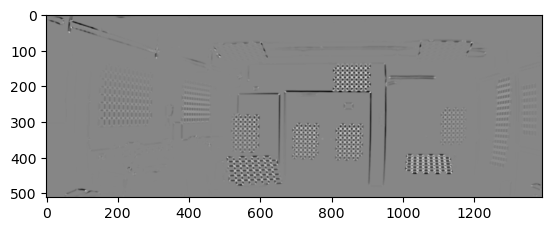

In [171]:
# Q11
img = cv2.imread('images/corners.jpg')
# Changing the order from bgr to rgb so that matplotlib can show it
b,g,r = cv2.split(img)
img = cv2.merge([r,g,b])
#plt.imshow(img)

gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
plt.imshow(gray, cmap=cm.gray)

block_size = 5
ksize = 11
k = 0.09
c=0
corner_response = cv2.cornerHarris(gray, block_size, ksize, k)
n = 5e5
print(corner_response.shape)
x = corner_response.shape[0]
y = corner_response.shape[1]
#print(corner_response[x][y])
#print(corner_response)
print(x)
print(y)
for a in range(2):
    print("A")

#print(xr)
for i in range(x):
    for j in range(y):
        if corner_response[i][j]>n:
            c +=1
print(c)


#corners = cornerHarrisDetection(gray)

# Display image
plt.imshow(corner_response, cmap='gray')

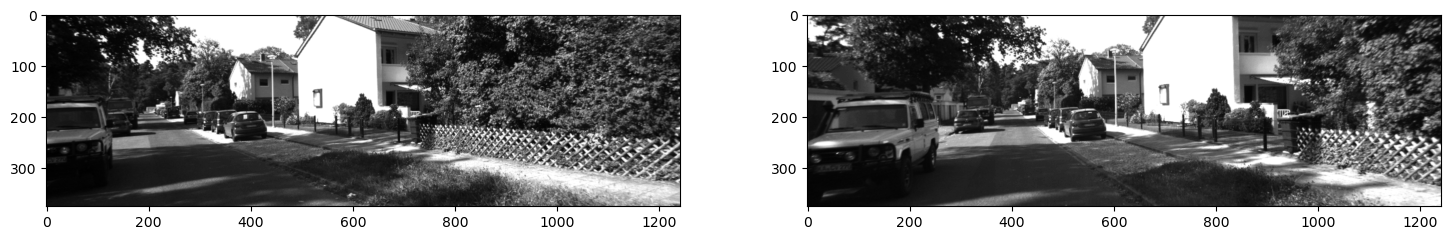

In [35]:
# Q18

img1 = cv2.imread('images/fundamental_img1.png')
img2 = cv2.imread('images/fundamental_img2.png')

b,g,r = cv2.split(img1) # Changing the order from bgr to rgb so that matplotlib can show it
img1 = cv2.merge([r,g,b])
b,g,r = cv2.split(img2) # Changing the order from bgr to rgb so that matplotlib can show it
img2 = cv2.merge([r,g,b])

gray1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)

plt.figure(figsize = (18,18))
plt.subplot(1,2,1)
plt.imshow(gray1, cmap = 'gray')
plt.subplot(1,2,2)
plt.imshow(gray2, cmap = 'gray')

In [39]:
#Q 19
p=0.95
w=0.6
up = np.log(1-p)
down = np.log(1-w*w)
k=up/down
print(k)

6.712567439010778


In [176]:
#Q 23
import matplotlib.pyplot as plt  
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score
import numpy as np

# Loading the data
X = np.loadtxt('clustering/clusters.txt', dtype=np.float32)
print(X.shape)
#print(X)
inertia_values = []
sil=[]
# Loop over different numbers of clusters to calculate 
for n in range(1, 21):
    km = KMeans(n_clusters=n)
    labels = km.fit_predict(X)
    km.fit(X)
    #score = silhouette_score(X, labels)
    #sil.appendnd(score)
    inertia_values.append(km.inertia_)

# Plot the elbow curve
#plt.plot(range(1, 21), inertia_values)
#plt.title('Elbow Method')
#plt.xlabel('Number of clusters')
#plt.ylabel('Inertia')
#plt.show()

(1000, 4)


C:\Users\micha\anaconda3\envs\02502_IA_1\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\micha\anaconda3\envs\02502_IA_1\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [55]:
#help(silhouette_score)

In [71]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#clusters.txt located in the clustering folder
X = np.loadtxt('clustering/clusters.txt')
print(X.shape)

X = StandardScaler().fit_transform(X)

print ("Number of data points ::", X.shape[0])
print("Number of features ::", X.shape[1])

pca = PCA(n_components=4)
principalComponents = pca.fit_transform(X)
#principalDf = pd.DataFrame(data = principalComponents
#             , columns = ['principal component 1', 'principal component 2','pc3'])
#display(principalDf)

#print(pca.explained_variance_ratio_[0])
sum=0
for i in range(len(pca.explained_variance_ratio_)):
    sum =sum+pca.explained_variance_ratio_[i]
    print(f"{i+1} sum: {sum}")

(1000, 4)
Number of data points :: 1000
Number of features :: 4
1 sum: 0.46483867461939976
2 sum: 0.812094786684233
3 sum: 0.9444276185268191
4 sum: 0.9999999999999999


In [73]:
#help(PCA)

## Fit a linear regression model

In this question you will fit a model 
$$
f(x) = ax^2 + bx + c
$$

to the data provided.

You should report the coefficients $a$, $b$ and $c$

Remember you can fit a LinReg model using the `LinearRegression` class from sklearn. 
Use the constructor `LinearRegression()` to create the object and then call the `fit` function on that object. 
Function signature for the fit function:

You can have a look at the documentation by using `help(LinearRegression)` or `%pdoc LinearRegression`

Note that you can use `np.hstack` to stack column vectors.

[-0.45779467]
a = 0.22
b = -0.46


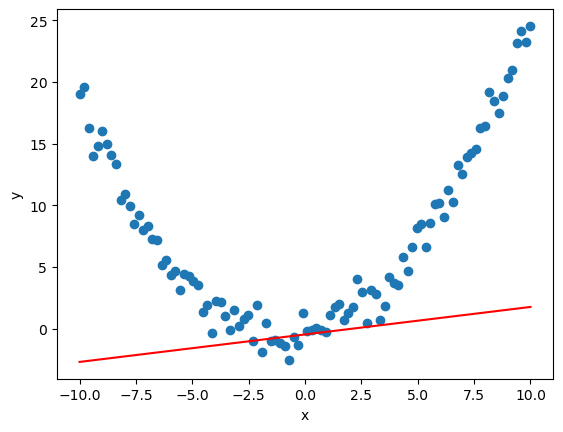

In [186]:
# 24 REGRESSION
import numpy as np
from sklearn.linear_model import LinearRegression

#Files located in regressino folder
x = np.loadtxt('regression/X.txt', dtype=np.float32).reshape(-1,1)
y = np.loadtxt('regression/y.txt', dtype=np.float32).reshape(-1,1)
#print(x.shape)
#print(y.shape)

# Reshape the data to 2D arrays
x = x.reshape(-1, 1)
xk = x*x
#print(x)
#print(xk)
y = y.reshape(-1, 1)
#print(x.shape)
#print(y.shape)

# Create a linear regression object and fit the data
reg = LinearRegression().fit(xk, y)

# Get the parameters of the linear regression model
a = reg.coef_[0][0]
b = reg.intercept_[0]
reg.predict(np.array([[0]]))

print(reg.intercept_)

# Print the parameters
print(f"a = {a:.2f}")
print(f"b = {b:.2f}")
# Plot the data and the linear regression line
plt.scatter(x, y)
plt.plot(x, reg.predict(x), color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.show()


In [183]:
#help(LinearRegression)

In [193]:
# Q28
def update(x, P, Z, H, R):
    ### Insert update function
    y = Z-np.dot(H, x)
    S = np.dot(np.dot(H, P),np.transpose(H))+R
    K = np.dot(np.dot(P, np.transpose(H)),np.linalg.pinv(S))
    print(f"K shape: {K.shape}")
    print(f"H shape: {H.shape}")
    #print(f"P shape: {P.shape}")
    #print(f"x shape: {x.shape}")
    #print(f"I shape: {I.shape}")
    print(f"np.dot(K, H).shape: {np.dot(K, H).shape}")
    x = x+np.dot(K, y)
    P = np.dot((I-np.dot(K, H)),P)
    return x, P


def predict(x, P, F, u):
    ### insert predict function
    x = np.dot(F, x)+u
    P = np.dot(np.dot(F, P),np.transpose(F))
    return x, P

# The initial state. The robot starts in position 0 with the velocity 0.
x = np.array([[5.9], # Position along the x-axis
              [5.3], # Velocity along the x-axis
              [1.5], # Position along the y-axis
              [-1.2],
              [0.2],
              [0]])# Velocity along the y-axis

#X = [5.9, 5.3, 1.5, -1.2, 0.2, 0]



# COVARIANCE MATRIX 
# The initial uncertainty
P = np.diag([0.5, 0.5, 0.2, 0.2, 0.01, 0.01])
#print(P)

# DONT CHANGE
# The external motion.
u = np.array([[0],
              [0],
              [0],
              [0],
                [0],
             [0]])


# DONT touch it?
# The transition matrix. 
# (or next state function). Used to predict the next state of the robot.
F = np.array([[1, 1, 0, 0],
              [0, 1, 0, 0],
              [0, 0, 1, 1],
              [0, 0, 0, 1]])

# DONT CHANGE IT
# The observation matrix. We only get the position as measurement. 
#H = np.array([[1, 0, 0, 0, 0, 0],[0,0,1,0, 0, 0]])
H = np.array([[1, 0, 0, 0, 0, 0],[0,0,0,0, 1, 0]])
#H = np.array([[1, 0, 0, 0],[0,0,1,0]])

# NOISE
# The measurement uncertainty 
#R = np.array([[0.2, 0.2],
#              [0.2, 0.2]])
R = np.diag([0.1, 0.1])
#print(R)


# DONT CHANGE IT
# The identity matrix. Simply a matrix with 1 in the diagonal and 0 elsewhere.
#asd = np.array([[1, 0, 0, 0],
#              [0, 1, 0, 0],
#              [0, 0, 1, 0],
#              [0, 0, 0, 1]])
I = np.diag([1, 1, 1, 1, 1, 1])


# You can use the following measurements or come up with your own. 
measurements_x = [6.2]
measurements_y = [5.6]
#print('INIT x')
#print(x)  
print('_____________')
for i in range(len(measurements_x)):
    z = np.array([[measurements_x[i]],
                  [measurements_y[i]]])
    ### Insert the rest
    x, P = update(x, P, z, H, R)
    print('update')
    print('X:')
    print(x)
    print("P:")
    print(P)
    print('_________________________')
    #x, P = predict(x, P, F, u)
    #print('predict')
    #print('X:')
    #print(x)
    #print("P:")
    #print(P)
    #print('_________________________')


_____________
K shape: (6, 2)
H shape: (2, 6)
np.dot(K, H).shape: (6, 6)
update
X:
[[ 6.15      ]
 [ 5.3       ]
 [ 1.5       ]
 [-1.2       ]
 [ 0.69090909]
 [ 0.        ]]
P:
[[0.08333333 0.         0.         0.         0.         0.        ]
 [0.         0.5        0.         0.         0.         0.        ]
 [0.         0.         0.2        0.         0.         0.        ]
 [0.         0.         0.         0.2        0.         0.        ]
 [0.         0.         0.         0.         0.00909091 0.        ]
 [0.         0.         0.         0.         0.         0.01      ]]
_________________________


In [137]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

#Data files are in the knn_classification folder
X = np.loadtxt('knn_classification/X.txt', dtype=np.float32)
y = np.loadtxt('knn_classification/y.txt', dtype=np.float32)
#print(f"X: {X.shape}")
#print(f"y: {y.shape}")

#X_train, X_test, y_train, y_test = train_test_split(X, y, train-size=0.35, test_size=0.65, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.65, test_size=0.35, random_state=42)
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"t_test: {y_test.shape}")

X_train: (650, 4)
X_test: (350, 4)
y_train: (650,)
t_test: (350,)


In [120]:
help(train_test_split)

Help on function train_test_split in module sklearn.model_selection._split:

train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)
    Split arrays or matrices into random train and test subsets.
    
    Quick utility that wraps input validation and
    ``next(ShuffleSplit().split(X, y))`` and application to input data
    into a single call for splitting (and optionally subsampling) data in a
    oneliner.
    
    Read more in the :ref:`User Guide <cross_validation>`.
    
    Parameters
    ----------
    *arrays : sequence of indexables with same length / shape[0]
        Allowed inputs are lists, numpy arrays, scipy-sparse
        matrices or pandas dataframes.
    
    test_size : float or int, default=None
        If float, should be between 0.0 and 1.0 and represent the proportion
        of the dataset to include in the test split. If int, represents the
        absolute number of test samples. If None, the value is set to 